<a href="https://colab.research.google.com/github/Somified/LeadRefine-Drug-likeliness/blob/main/LeadRefine_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [2]:
!conda install -c conda-forge rdkit -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: / - \ | done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [3]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [4]:
!conda install -c conda-forge rdkit -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: \ | / - \ | / done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



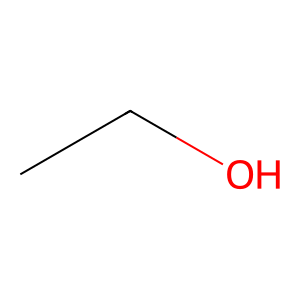

In [5]:
import sys

# Add the path to the conda site-packages.
# The condacolab installation used Python 3.11.
# The condacolab base environment is typically installed in /usr/local.
conda_site_packages_path = '/usr/local/lib/python3.11/site-packages'
if conda_site_packages_path not in sys.path:
    sys.path.append(conda_site_packages_path)

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

mol = Chem.MolFromSmiles("CCO")
Draw.MolToImage(mol)

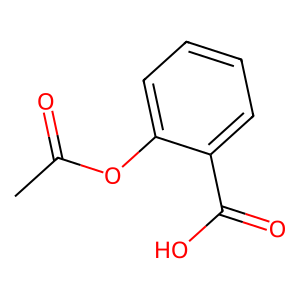

In [6]:
smiles = "CC(=O)Oc1ccccc1C(=O)O"  # aspirin
mol = Chem.MolFromSmiles(smiles)

Draw.MolToImage(mol, size=(300, 300))

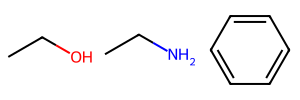

In [7]:
smiles_list = ["CCO", "CCN", "c1ccccc1"]

mols = [Chem.MolFromSmiles(s) for s in smiles_list]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(100,100))

In [8]:
from rdkit.Chem import Descriptors

Descriptors.MolWt(mol), Descriptors.MolLogP(mol)

(180.15899999999996, 1.3101)

In [9]:
Draw.MolToFile(mol, "aspirin.png", size=(400,400))

In [10]:
from rdkit.Chem import Descriptors, Lipinski

mol_weight = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)

hbd = Lipinski.NumHDonors(mol)
hba = Lipinski.NumHAcceptors(mol)

tpsa = Descriptors.TPSA(mol)
rot_bonds = Lipinski.NumRotatableBonds(mol)

In [11]:
print("Molecular Properties")
print("--------------------")
print(f"Molecular Weight      : {mol_weight:.2f}")
print(f"LogP                  : {logp:.2f}")
print(f"H-bond Donors (HBD)   : {hbd}")
print(f"H-bond Acceptors (HBA): {hba}")
print(f"TPSA                 : {tpsa:.2f}")
print(f"Rotatable Bonds      : {rot_bonds}")

Molecular Properties
--------------------
Molecular Weight      : 180.16
LogP                  : 1.31
H-bond Donors (HBD)   : 1
H-bond Acceptors (HBA): 3
TPSA                 : 63.60
Rotatable Bonds      : 2


In [12]:
rules = {
    "molecular_weight": 500,
    "logp": 5,
    "hbd": 5,
    "hba": 10,
    "tpsa": 140,
    "rotatable_bonds": 10
}


In [13]:
properties = {
    "molecular_weight": Descriptors.MolWt(mol),
    "logp": Descriptors.MolLogP(mol),
    "hbd": Lipinski.NumHDonors(mol),
    "hba": Lipinski.NumHAcceptors(mol),
    "tpsa": Descriptors.TPSA(mol),
    "rotatable_bonds": Lipinski.NumRotatableBonds(mol)
}

In [26]:
violations = []

if properties["molecular_weight"] > rules["molecular_weight"]:
    violations.append({
        "property": "molecular_weight",
        "value": properties["molecular_weight"],
        "limit": rules["molecular_weight"]
    })

if properties["logp"] > rules["logp"]:
    violations.append({
        "property": "logp",
        "value": properties["logp"],
        "limit": rules["logp"]
    })

if properties["hbd"] > rules["hbd"]:
    violations.append({
        "property": "hbd",
        "value": properties["hbd"],
        "limit": rules["hbd"]
    })

if properties["hba"] > rules["hba"]:
    violations.append({
        "property": "hba",
        "value": properties["hba"],
        "limit": rules["hba"]
    })

if properties["tpsa"] > rules["tpsa"]:
    violations.append({
        "property": "tpsa",
        "value": properties["tpsa"],
        "limit": rules["tpsa"]
    })

if properties["rotatable_bonds"] > rules["rotatable_bonds"]:
    violations.append({
        "property": "rotatable_bonds",
        "value": properties["rotatable_bonds"],
        "limit": rules["rotatable_bonds"]
    })


In [27]:
print("Violations:")

if not violations:
    print("None (passes basic drug-likeness rules)")
else:
    for prop, value in violations:
        print(f"- {prop} violated (value = {value})")

Violations:


ValueError: too many values to unpack (expected 2)

In [16]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

def analyze_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    properties = {
        "molecular_weight": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "tpsa": Descriptors.TPSA(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol)
    }

    rules = {
        "molecular_weight": 500,
        "logp": 5,
        "hbd": 5,
        "hba": 10,
        "tpsa": 140,
        "rotatable_bonds": 10
    }

    violations = []
    for prop in rules:
        if properties[prop] > rules[prop]:
            violations.append((prop, properties[prop]))

    return properties, violations


In [28]:
properties, violations = analyze_smiles("CCCCCCCCCCCCCCCC")

print("Violations:")
if not violations:
    print("None")
else:
    for prop, value in violations:
        print(f"- {prop}: {value}")

ValueError: too many values to unpack (expected 2)

In [29]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

def analyze_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    properties = {
        "molecular_weight": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "tpsa": Descriptors.TPSA(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol)
    }

    rules = {
        "molecular_weight": 500,
        "logp": 5,
        "hbd": 5,
        "hba": 10,
        "tpsa": 140,
        "rotatable_bonds": 10
    }

    violations = []
    for prop in rules:
        if properties[prop] > rules[prop]:
           violations.append({
    "property": prop,
    "value": properties[prop],
    "limit": rules[prop]
})


    result = {
        "smiles": smiles,
        "properties": properties,
        "violations": violations,
        "num_violations": len(violations)
    }

    return result


In [30]:
result = analyze_smiles("CCCCCCCCCCCCCCCC")

print("SMILES:", result["smiles"])
print("\nProperties:")
for k, v in result["properties"].items():
    print(f"{k}: {v}")

print("\nViolations:")
if result["num_violations"] == 0:
    print("None")
else:
    for v in result["violations"]:
        print(f"- {v['property']} ({v['value']} > {v['limit']})")


SMILES: CCCCCCCCCCCCCCCC

Properties:
molecular_weight: 226.44799999999992
logp: 6.487600000000007
hbd: 0
hba: 0
tpsa: 0.0
rotatable_bonds: 13

Violations:
- logp (6.487600000000007 > 5)
- rotatable_bonds (13 > 10)


In [31]:
violation_meanings = {
    "molecular_weight": {
        "category": "size",
        "issue": "Molecule may be too large for oral absorption"
    },
    "logp": {
        "category": "lipophilicity",
        "issue": "Excessive hydrophobicity may reduce solubility"
    },
    "hbd": {
        "category": "polarity",
        "issue": "Too many hydrogen bond donors"
    },
    "hba": {
        "category": "polarity",
        "issue": "Too many hydrogen bond acceptors"
    },
    "tpsa": {
        "category": "polarity",
        "issue": "High polar surface area may hinder permeability"
    },
    "rotatable_bonds": {
        "category": "flexibility",
        "issue": "High flexibility may reduce binding efficiency"
    }
}

In [32]:
for v in result["violations"]:
    meaning = violation_meanings[v["property"]]
    v["category"] = meaning["category"]
    v["issue"] = meaning["issue"]

In [33]:
SUGGESTION_MAP = {
    "size": [
        "Reduce molecular size by removing bulky substituents",
        "Eliminate redundant ring systems"
    ],
    "lipophilicity": [
        "Introduce polar functional groups",
        "Reduce hydrophobic substituents or aromatic rings"
    ],
    "polarity": [
        "Reduce the number of hydrogen bond donors/acceptors",
        "Mask polar groups using bioisosteres"
    ],
    "flexibility": [
        "Increase rigidity by introducing ring systems",
        "Reduce the number of rotatable bonds"
    ]
}

In [34]:
print(type(violations[0]))
print(violations[0])
for v in violations:
    category = v["category"]
    v["suggestions"] = SUGGESTION_MAP.get(category, [])

<class 'dict'>
{'property': 'logp', 'value': 6.487600000000007, 'limit': 5}


KeyError: 'category'